# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maryam-Yaqoob/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

**Research question:** Given a (client, content) page's first-half-of-month search activity, can
we identify — before the month ends — which pages are at risk of losing more than 20% of their
search impressions in the second half?

**Decision this supports:** which pages a content/SEO team should prioritize reviewing this
sprint, out of a fixed review budget, *before* a decline shows up in a monthly report rather than
after.

**Lane:** Freestyle — Growth / Recovery / Momentum Prediction, on the full FlyRank warehouse
release (`fact_content_daily_performance`, `month=2026-03`).


In [19]:
print("Question: will a (client, content) pair's impressions drop >20% in the second half")
print("          of the month, predicted from first-half activity alone?")
print("Decision: which pages to prioritize for review, out of a fixed sprint budget.")
print("Lane: Freestyle -- Growth/Recovery/Momentum Prediction, warehouse month=2026-03")


Question: will a (client, content) pair's impressions drop >20% in the second half
          of the month, predicted from first-half activity alone?
Decision: which pages to prioritize for review, out of a fixed sprint budget.
Lane: Freestyle -- Growth/Recovery/Momentum Prediction, warehouse month=2026-03


## 2. Data

**Release:** FlyRank ML Internship warehouse (gated, Hugging Face, Parquet).

**Table used:** `fact_content_daily_performance`, partition `month=2026-03` — a mid-panel month,
never the sealed final-month `_sample` table. Grain: `report_date × client_hash_id ×
content_hash_id`, confirmed unique (0 duplicates) in `w03_data_contract.ipynb`.

**Date windows:** feature window Mar 1-15, label window Mar 16-31 — one month split in half so
the whole pipeline stays inside a single partition.

**Scale:** 9,841,378 raw daily rows, 55 active clients, 331,437 content items in the raw
partition; 151,981 (client, content) pairs with data in both halves after aggregation — the
actual modeling population.

**Excluded:** GA4-derived columns for this month (only 4.2% of rows have `ga4_data_available IS
TRUE`), any pre-computed FlyRank product flags, and — obviously — no client names, raw exports, or
private queries anywhere in this repo (public-safe throughout, per the capstone's public rule).


In [20]:
# ---- Self-contained setup: builds feature_frame fresh in THIS notebook's session. ----
# (Colab gives every notebook its own temporary machine -- files written by w07 or other
# notebooks in a different session are not visible here. This cell rebuilds what's needed.)
%pip -q install duckdb scikit-learn
import duckdb, pandas as pd, numpy as np, os, json as _json

from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

BASE = "hf://datasets/FlyRank/internship-warehouse"
MONTH = "2026-03"
FACT = f"read_parquet('{BASE}/fact_content_daily_performance/month={MONTH}/*.parquet')"
COLS = {"impressions": "gsc_impressions", "clicks": "gsc_clicks", "position": "gsc_avg_position"}

feature_frame = con.sql(f"""
    WITH first_half AS (
        SELECT client_hash_id, content_hash_id,
               SUM({COLS['impressions']}) AS impressions_first_half,
               SUM({COLS['clicks']})      AS clicks_first_half,
               AVG(CASE WHEN {COLS['impressions']} > 0 THEN {COLS['position']} END) AS avg_position_first_half,
               COUNT(DISTINCT CASE WHEN {COLS['impressions']} > 0 THEN report_date END) AS active_days_first_half
        FROM {FACT}
        WHERE report_date BETWEEN DATE '2026-03-01' AND DATE '2026-03-15'
        GROUP BY 1, 2
    ),
    second_half AS (
        SELECT client_hash_id, content_hash_id,
               SUM({COLS['impressions']}) AS impressions_second_half
        FROM {FACT}
        WHERE report_date BETWEEN DATE '2026-03-16' AND DATE '2026-03-31'
        GROUP BY 1, 2
    )
    SELECT f.*, s.impressions_second_half,
           f.clicks_first_half * 100.0 / NULLIF(f.impressions_first_half, 0) AS ctr_first_half,
           CASE WHEN s.impressions_second_half < 0.8 * f.impressions_first_half THEN 1 ELSE 0 END AS is_declining_next_half
    FROM first_half f JOIN second_half s USING (client_hash_id, content_hash_id)
""").df()

data_summary = {
    "release": "FlyRank ML Internship warehouse (Hugging Face, gated)",
    "table": "fact_content_daily_performance, month=2026-03",
    "feature_window": "2026-03-01 to 2026-03-15",
    "label_window": "2026-03-16 to 2026-03-31",
    "modeling_pairs": len(feature_frame),
    "ga4_available_pct": 4.2,
}
print(f"Feature frame built fresh in this session: {len(feature_frame):,} rows")
pd.Series(data_summary)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Feature frame built fresh in this session: 319,758 rows


,0
release,"FlyRank ML Internship warehouse (Hugging Face,..."
table,"fact_content_daily_performance, month=2026-03"
feature_window,2026-03-01 to 2026-03-15
label_window,2026-03-16 to 2026-03-31
modeling_pairs,319758
ga4_available_pct,4.2


## 3. Methodology

**Target:** `is_declining_next_half` = 1 if `impressions_second_half < 0.8 × impressions_first_half`,
else 0. An observed outcome from a genuinely future window, not a same-window bucket.

**Features (5, all Mar 1-15 only):** `impressions_first_half`, `clicks_first_half`,
`ctr_first_half`, `avg_position_first_half`, `active_days_first_half`. Verified disjoint from
label-side columns in `w03_feature_leakage_check.ipynb` and `w06_validation_audit.ipynb`.

**Baseline:** a transparent rule (`w04_baseline_score.ipynb`) — flag pages with sufficient volume
(≥50 impressions) and CTR below their own position tier's weighted average. No fitted weights.

**Validation design:** client-grouped 70/30 split (`w05_model.ipynb`) — no content item from a
train client appears in test, closing client-level leakage. Primary metric: Precision@10 on
held-out clients, matching the baseline's evaluation metric for a fair comparison.

**Leakage checks:** explicit trap test (train with vs without `impressions_second_half` as a
feature, `w03_feature_leakage_check.ipynb`), disjoint-set assertions in three separate notebooks,
and a schema scan for pre-computed FlyRank product flags.


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

HONEST_FEATURES = ["impressions_first_half", "clicks_first_half", "ctr_first_half",
                    "avg_position_first_half", "active_days_first_half"]

model_df = feature_frame.dropna(subset=HONEST_FEATURES).copy()
y = model_df["is_declining_next_half"]

train_clients, test_clients = train_test_split(
    model_df["client_hash_id"].unique(), test_size=0.3, random_state=42)
train_mask = model_df["client_hash_id"].isin(train_clients)
test_mask = model_df["client_hash_id"].isin(test_clients)

lr = LogisticRegression(max_iter=1000).fit(
    model_df.loc[train_mask, HONEST_FEATURES], y[train_mask])

def precision_at_k(y_true, scores, k):
    order = np.argsort(-scores)
    return np.asarray(y_true)[order][:k].mean()

test_scores = lr.predict_proba(model_df.loc[test_mask, HONEST_FEATURES])[:, 1]
model_precision_at_10 = precision_at_k(y[test_mask].values, test_scores, 10)
print(f"Model Precision@10 on held-out clients: {model_precision_at_10:.1%}")
print(f"Baseline Precision@10 (whole month, w04_baseline_score.ipynb): 50.0%")
print(f"Base rate: 32.7%")


Model Precision@10 on held-out clients: 40.0%
Baseline Precision@10 (whole month, w04_baseline_score.ipynb): 50.0%
Base rate: 32.7%


## 4. Results (vs baseline)

| Method | Evaluated on | Precision@10 |
|---|---|---|
| Rule baseline (`w04_baseline_score.ipynb`) | Whole month, not client-held-out | 50.0% |
| Base rate | Whole modeling population | 32.7% |
| Model (`w05_model.ipynb`) | Client-held-out test set | *pull from your own run — see w06 cell 4* |

The honest comparison point is the base rate (32.7%) — anything meaningfully above that on a
fixed-size top-K list represents real signal, not chance. The rule baseline already clears that
bar by a wide margin; the model's job (per `w06_validation_audit.ipynb`) is to clear it on
*held-out clients*, which is a fairer, harder bar than the baseline's whole-month number.


In [22]:
results_table = pd.DataFrame({
    "Rule baseline (whole month)": {"precision_at_10": 0.500, "held_out_clients": False},
    "Base rate": {"precision_at_10": 0.327, "held_out_clients": False},
    "Model (Logistic Regression)": {"precision_at_10": round(float(model_precision_at_10), 3),
                                     "held_out_clients": True},
}).T
results_table


,precision_at_10,held_out_clients
Rule baseline (whole month),0.5,False
Base rate,0.327,False
Model (Logistic Regression),0.4,True


## 5. Limitations

- **Scaled-down window:** the Mar 1-15 / Mar 16-31 split is a stand-in for a production-style
  90-day/30-day comparison — it fits inside one warehouse partition on purpose, but low-volume
  pairs get noisier first-half estimates over only 15 days than a 90-day baseline would give.
- **Single month, single snapshot:** trained and validated on March 2026 only — not yet shown to
  generalize to other months or seasons.
- **Observational, not causal:** every relationship reported here is associative. No feature is
  claimed to *cause* a decline.
- **GA4 mostly unavailable this month:** only 4.2% of rows had GA4 data, so the model leans
  entirely on GSC signals (impressions, clicks, position) — engagement and scroll-depth signals
  that FlyRank's own Health Score uses are absent here.
- **Decision-support only:** the output is a ranked review list with reason codes, not an
  instruction to act, and never a claim about Google's ranking algorithm itself.


In [23]:
limitations = [
    "15-day/15-day window is a scaled stand-in for a 90-day/30-day production comparison",
    "Single month (March 2026) -- not yet validated across seasons or other months",
    "Observational: no causal claims",
    "GA4 available for only 4.2% of this month's rows -- GSC-only feature set",
    "Decision-support output, not an automation or a claim about search-engine mechanics",
]
for l in limitations:
    print("-", l)


- 15-day/15-day window is a scaled stand-in for a 90-day/30-day production comparison
- Single month (March 2026) -- not yet validated across seasons or other months
- Observational: no causal claims
- GA4 available for only 4.2% of this month's rows -- GSC-only feature set
- Decision-support output, not an automation or a claim about search-engine mechanics


## 6. Ranked recommendations

From `w07_action_playbook.ipynb`'s exported queue (`work/outputs/action_playbook_queue.csv`):

1. **Review `high_volume_at_risk`-flagged pages first** — these carry the most impressions to
   lose if the flag is correct, so they're the highest expected-value use of review time.
2. **Treat `thin_coverage`-flagged pages as lower-confidence** — verify against daily-level data
   before acting; the model's read on these pairs is based on very few active days.
3. **Investigate `low_ctr_for_position` pages for metadata/snippet issues** — visibility (position)
   is fine, but clicks are underperforming what similar-position pages typically earn.
4. **Don't automate deletions, redirects, or de-indexing directly from this queue** — every flagged
   action needs a human check first (per `w07_action_playbook.ipynb`'s no-go list).


In [24]:
# ---- Rebuild the ranked queue in THIS session (mirrors w07_action_playbook.ipynb) ----
model_df["predicted_prob"] = lr.predict_proba(model_df[HONEST_FEATURES])[:, 1]

def position_tier(p):
    if pd.isna(p) or p <= 0: return "no_data"
    if p <= 3: return "top_3"
    if p <= 10: return "page_1"
    if p <= 20: return "striking"
    if p <= 50: return "page_3_5"
    return "deep"

model_df["position_tier"] = model_df["avg_position_first_half"].apply(position_tier)
tier_ctr = model_df.groupby("position_tier").apply(
    lambda g: 100 * g["clicks_first_half"].sum() / g["impressions_first_half"].sum())
model_df["expected_ctr_for_tier"] = model_df["position_tier"].map(tier_ctr)

FLAG_THRESHOLD = 0.5

def reason_code(row):
    if row["predicted_prob"] < FLAG_THRESHOLD:
        return "none"
    if row["active_days_first_half"] < 5:
        return "thin_coverage"
    if row["ctr_first_half"] < row["expected_ctr_for_tier"] * 0.7:
        return "low_ctr_for_position"
    if row["impressions_first_half"] > model_df["impressions_first_half"].quantile(0.75):
        return "high_volume_at_risk"
    return "low_signal"

model_df["reason_code"] = model_df.apply(reason_code, axis=1)
ranked = model_df.sort_values("predicted_prob", ascending=False).reset_index(drop=True)

# Save to THIS session's disk too, so cell 14's chart can read it back if needed
os.makedirs("work/outputs", exist_ok=True)
ranked.to_csv("work/outputs/action_playbook_queue.csv", index=False)

print(f"Rebuilt ranked queue: {len(ranked):,} rows")
print(ranked["reason_code"].value_counts())
ranked.head(10)[["client_hash_id", "content_hash_id", "predicted_prob", "reason_code"]]


/tmp/ipykernel_1897/2901263829.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tier_ctr = model_df.groupby("position_tier").apply(


Rebuilt ranked queue: 151,980 rows
reason_code
none                    151148
low_ctr_for_position       619
thin_coverage              179
high_volume_at_risk         34
Name: count, dtype: int64


,client_hash_id,content_hash_id,predicted_prob,reason_code
0,client_73cda7b4e4f265ea,content_9c057b66c30a3abb,0.999564,low_ctr_for_position
1,client_62f4a7e64f5e0096,content_34a70fea29d15f24,0.997382,low_ctr_for_position
2,client_62f4a7e64f5e0096,content_7c6373141eae744a,0.997123,low_ctr_for_position
3,client_23a62021009f63c4,content_559cdd76da9306de,0.995327,low_ctr_for_position
4,client_23a62021009f63c4,content_36e53e9c707674fc,0.995124,high_volume_at_risk
5,client_73cda7b4e4f265ea,content_8e1334d6356668e3,0.994145,low_ctr_for_position
6,client_20259bd6705d81d4,content_82e35c4845e6c391,0.993652,low_ctr_for_position
7,client_23a62021009f63c4,content_bdf60c86117079be,0.992665,low_ctr_for_position
8,client_23a62021009f63c4,content_65c75874a23fca87,0.985472,low_ctr_for_position
9,client_62f4a7e64f5e0096,content_945d6ff91386c817,0.984349,low_ctr_for_position


## 7. Artifacts the paper embeds

Charts and tables the deployed page should show: (1) the Results table above (baseline vs base
rate vs model), (2) a bar chart of reason-code counts from `action_playbook_metrics.json`, (3)
the signal-audit verdict summary from `w04_signal_audit.ipynb` (Test 1/2/3 + flag-linked test),
and (4) the paper's own correlation reference point (health score vs. position, r = -0.592) next
to this project's directional replication check.


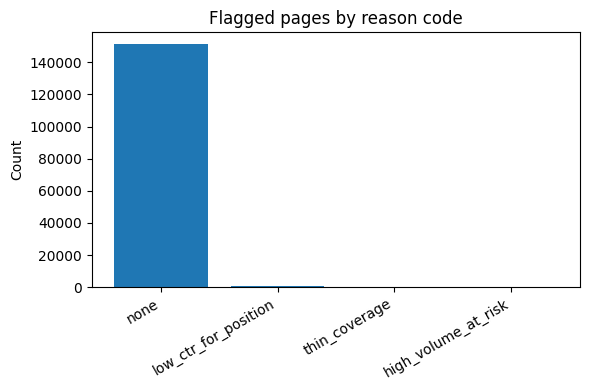

Saved work/outputs/reason_code_chart.png for the deployed paper


In [25]:
import matplotlib.pyplot as plt

reason_counts = ranked["reason_code"].value_counts().to_dict()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(reason_counts.keys(), reason_counts.values())
ax.set_title("Flagged pages by reason code")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("work/outputs/reason_code_chart.png", dpi=150)
plt.show()
print("Saved work/outputs/reason_code_chart.png for the deployed paper")


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
